# 9. Final Model Evaluation and Explainability

## Objective

The previous experiments identified XGBoost as the strongest modeling
approach for credit default prediction.

Hyperparameter tuning was performed using the training data, while the
validation set was used to select the final classification threshold.

The selected classification threshold is:

**0.55**

This notebook performs the final stage of the machine learning workflow:

- Rebuild the selected XGBoost model using the chosen hyperparameters.
- Train the final model using the combined training and validation data.
- Evaluate the model once on the previously untouched test set.
- Analyze model behavior and feature importance.
- Save the final trained model for future deployment.

The test set is used only for this final evaluation.

## 1. Setup and Data Preparation

The same data preparation utilities and original train-validation-test split
are reused to maintain consistency with previous experiments.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from xgboost import XGBClassifier


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)


from src.modeling_utils import (
    load_data,
    split_data,
    build_preprocessor
)

print("Project root:", PROJECT_ROOT)

Project root: d:\1-PERSONAL\HOC-TAP\DS\credit-risk-default-prediction


In [2]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_default_features.csv"
)

X, y = load_data(DATA_PATH)

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_data(X, y)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (21000, 36)
Validation: (4500, 36)
Test: (4500, 36)


## 2. Final Model Configuration

The best XGBoost hyperparameters identified during model tuning are loaded
from the previous experiment.

The classification threshold selected using the validation set is fixed at
**0.55**.

Neither the model configuration nor the threshold will be changed after
evaluating the test set.

In [4]:
BEST_PARAMS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "best_xgb_params.json"
)

with open(BEST_PARAMS_PATH, "r") as f:
    best_params = json.load(f)

best_params

{'classifier__subsample': 0.8,
 'classifier__n_estimators': 200,
 'classifier__max_depth': 4,
 'classifier__learning_rate': 0.03,
 'classifier__colsample_bytree': 1.0}

In [5]:
xgb_params = {
    key.replace("classifier__", ""): value
    for key, value in best_params.items()
}

xgb_params

{'subsample': 0.8,
 'n_estimators': 200,
 'max_depth': 4,
 'learning_rate': 0.03,
 'colsample_bytree': 1.0}

In [6]:
FINAL_THRESHOLD = 0.55

print("Final classification threshold:", FINAL_THRESHOLD)

Final classification threshold: 0.55


## 3. Final Training Dataset

Model selection and threshold optimization are now complete.

The training and validation sets are combined to provide more data for
training the final model.

The test set remains completely untouched.

In [7]:
X_train_final = pd.concat(
    [X_train, X_val],
    axis=0
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
)

print("Final training set:", X_train_final.shape)
print("Final test set:", X_test.shape)

Final training set: (25500, 36)
Final test set: (4500, 36)


In [8]:
negative_count = (y_train_final == 0).sum()
positive_count = (y_train_final == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print("Negative:", negative_count)
print("Positive:", positive_count)
print(
    "scale_pos_weight:",
    round(scale_pos_weight, 4)
)

Negative: 19860
Positive: 5640
scale_pos_weight: 3.5213


## 4. Train Final XGBoost Model

The final XGBoost model is trained using the combined training and
validation datasets with the hyperparameters selected during tuning.

The test dataset is excluded from model training.

In [9]:
tree_preprocessor = build_preprocessor(
    X_train_final,
    scale_numeric=False
)

In [10]:
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                **xgb_params,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [11]:
final_model.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

## 5. Final Test Evaluation

The final model is evaluated once on the previously untouched test set.

The fixed classification threshold of **0.55** is used to convert predicted
default probabilities into class predictions.

In [12]:
y_test_prob = final_model.predict_proba(
    X_test
)[:, 1]

In [13]:
y_test_pred = (
    y_test_prob >= FINAL_THRESHOLD
).astype(int)

In [14]:
final_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred
    ),

    "Precision": precision_score(
        y_test,
        y_test_pred
    ),

    "Recall": recall_score(
        y_test,
        y_test_pred
    ),

    "F1": f1_score(
        y_test,
        y_test_pred
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_test_prob
    ),

    "PR_AUC": average_precision_score(
        y_test,
        y_test_prob
    )
}

final_results_df = pd.DataFrame(
    [final_results],
    index=["Final XGBoost"]
)

final_results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Final XGBoost,0.7838,0.51,0.5914,0.5477,0.7855,0.5661


## 6. Final Test Confusion Matrix

The confusion matrix is used to examine the final model's classification
errors on unseen test data.

Particular attention is given to false negatives because they represent
customers who actually default but are predicted as non-default.

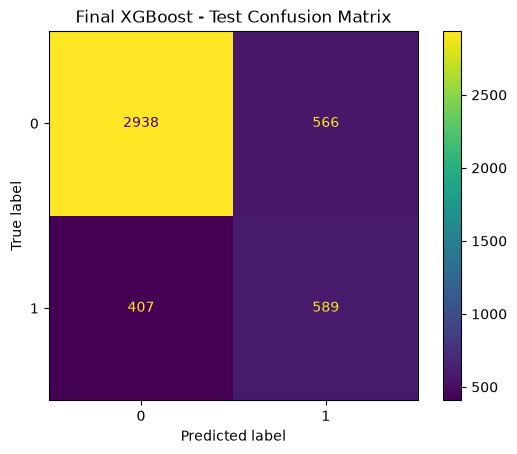

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title(
    "Final XGBoost - Test Confusion Matrix"
)

plt.show()

In [16]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 2938
False Positive: 566
False Negative: 407
True Positive : 589


## 7. Feature Importance

XGBoost feature importance is examined to identify which variables
contribute most strongly to the model's predictions.

In [17]:
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    final_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

top_features = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

top_features

,Feature,Importance
21,num__MAX_PAYMENT_DELAY,0.385286
20,num__NUM_DELAYED_MONTHS,0.192616
2,num__PAY_0,0.074713
25,num__MAX_BILL_AMT,0.022286
26,num__AVG_PAY_AMT,0.018913
3,num__PAY_2,0.016890
29,num__CREDIT_UTILIZATION,0.016368
15,num__PAY_AMT2,0.014282
0,num__LIMIT_BAL,0.013396
24,num__AVG_BILL_AMT,0.012586


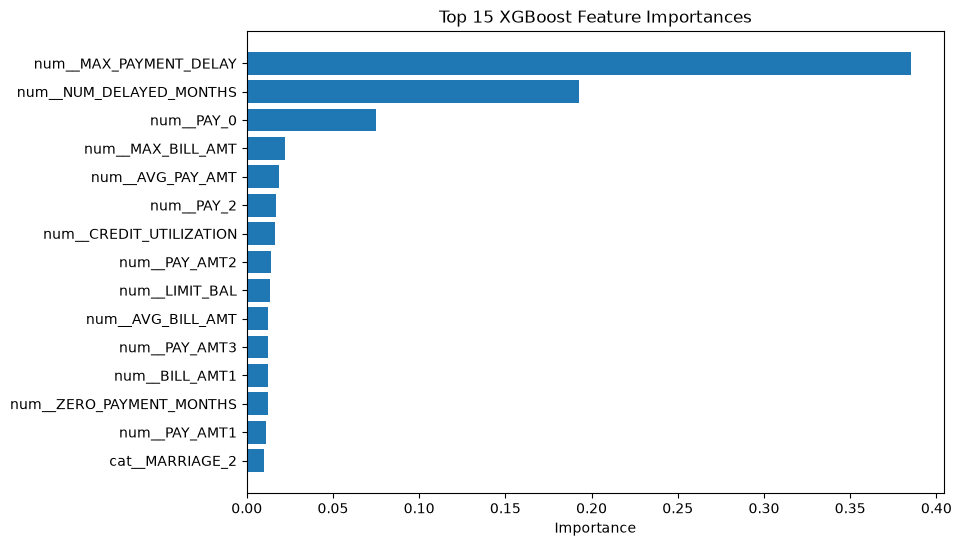

In [18]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")

plt.show()

In [20]:
FINAL_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "final_test_results.csv"
)

final_results_df.to_csv(
    FINAL_RESULTS_PATH
)

feature_importance_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "feature_importance.csv",
    index=False
)

In [22]:
MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "final_xgboost_model.joblib"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

In [23]:
import joblib
joblib.dump(
    final_model,
    MODEL_PATH
)

print("Saved model:", MODEL_PATH)

Saved model: d:\1-PERSONAL\HOC-TAP\DS\credit-risk-default-prediction\models\final_xgboost_model.joblib


In [24]:
MODEL_CONFIG_PATH = (
    PROJECT_ROOT
    / "models"
    / "model_config.json"
)

with open(MODEL_CONFIG_PATH, "w") as f:
    json.dump(
        {
            "classification_threshold": 0.55
        },
        f,
        indent=4
    )

## 8. Final Model Findings

The tuned XGBoost model was evaluated once on the previously untouched
test dataset using the fixed classification threshold of 0.55.

Final test performance:

- Accuracy: 78.38%
- Precision: 51.00%
- Recall: 59.14%
- F1-score: 54.77%
- ROC-AUC: 78.55%
- PR-AUC: 56.61%

The final test results are very similar to the validation results,
indicating that the model generalizes consistently to unseen data.

The selected threshold improves the balance between precision and recall,
allowing the model to identify approximately 59% of actual default cases
while maintaining a precision of approximately 51%.

The test dataset was not used during model selection, hyperparameter tuning,
or threshold optimization.
